# Week-27

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

reconstruction_metric_palette = {
    "Connectance": "#4E5A9A",          # muted indigo
    "MeanGenerality": "#A23E48",       # muted wine red
    "MeanVulnerability": "#B07D2B",    # muted bronze
    "MeanTrophicHeight": "#2F6F73",    # muted blue-teal
}

- we are not running the model enought times for the statistic to be stable enough, because the first 10  runs are good, but then they got worse
- each tab is a metric, 
- we need to run more times (iterations) the model for each 290 foodweb
- check each foodweb if necesario, appling Athen method
- 1. correr el numero de veces necesarias para que los outliers que no cumplan (esten dentro del rango) que se sustituyan de las 20 inteciones solo las que no cumplen los thresholds
- 2. correrlo al menos 200 veces

- for generality do the same
- for standar mean deviation use the 10%
- for standar error, we also need to handle the foodwebs/iterations that are grater than 0.1
- 

---

- read paper Joining the dots:
- paired Wilcoxon signed ranked test, Table 3.

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

TRAIN_RATIO_TARGET = 90
NODES_THRESHOLD = 0
K_TARGET = None

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita"
    / "statistical_tests/athen"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS = [
    "TestTP", "TestFP", "TestFN", "TestTN",
    "ROC_AUC", "PR_AUC", "F1Score", "TestMCC",
    "Precision", "Recall", "TestTSS",
]

def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)

def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem

def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    keep_cols = ["K", "TrainRatio", "ExperimentID"] + METRICS
    present_cols = [c for c in keep_cols if c in df.columns]
    df = df[present_cols].copy()

    for c in present_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "TrainRatio" not in df.columns:
        return None

    df = df[df["TrainRatio"] == TRAIN_RATIO_TARGET].copy()

    if K_TARGET is not None and "K" in df.columns:
        df = df[df["K"] == K_TARGET].copy()

    if df.empty:
        return None

    foodweb = parse_foodweb_from_name(csv_path.name)

    df["Foodweb"] = foodweb
    df["FW_KEY"] = normalize_fw_label(foodweb)
    df["Version"] = version
    df["Run"] = df["ExperimentID"] if "ExperimentID" in df.columns else np.arange(1, len(df) + 1)
    df["file"] = csv_path.name

    for metric in METRICS:
        if metric not in df.columns:
            df[metric] = np.nan

    return df[["Foodweb", "FW_KEY", "Version", "Run", "file"] + METRICS]

def load_folder(folder: Path, pattern: str, version: str):
    dfs = []
    for p in sorted(folder.glob(pattern)):
        df = load_one_csv(p, version)
        if df is not None:
            dfs.append(df)

    if not dfs:
        raise RuntimeError(f"No valid files found for {version}")

    return pd.concat(dfs, ignore_index=True)

run_df = pd.concat(
    [
        load_folder(
            RESULTS_DIR_ORIGINAL,
            "*_tax_mass_results_random_wlnm_original.csv",
            "original",
        ),
        load_folder(
            RESULTS_DIR_DIR_NEG,
            "*_tax_mass_results_random_wlnm_dir_neg.csv",
            "dir_neg",
        ),
    ],
    ignore_index=True,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next(c for c in meta.columns if c.lower() == "foodweb")
nodes_col = next(c for c in meta.columns if c.lower() == "nodes")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
allowed_fw_keys = set(meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"])

run_df = run_df[run_df["FW_KEY"].isin(allowed_fw_keys)].copy()

web_df = (
    run_df
    .groupby(["Foodweb", "FW_KEY", "Version"], as_index=False)
    .agg({**{m: "mean" for m in METRICS}, "Run": "count"})
    .rename(columns={"Run": "ValidRuns"})
)

wide_df = web_df.pivot(index=["Foodweb", "FW_KEY"], columns="Version", values=METRICS)
wide_df.columns = [f"{version}_{metric}" for metric, version in wide_df.columns]
wide_df = wide_df.reset_index()

valid_runs_wide = web_df.pivot(index=["Foodweb", "FW_KEY"], columns="Version", values="ValidRuns")
valid_runs_wide.columns = [f"{version}_ValidRuns" for version in valid_runs_wide.columns]
valid_runs_wide = valid_runs_wide.reset_index()

wide_df = valid_runs_wide.merge(wide_df, on=["Foodweb", "FW_KEY"], how="outer")

common_keys = (
    web_df.groupby("FW_KEY")["Version"]
    .nunique()
    .loc[lambda s: s == 2]
    .index
)

web_common_df = web_df[web_df["FW_KEY"].isin(common_keys)].copy()
wide_common_df = wide_df[wide_df["FW_KEY"].isin(common_keys)].copy()

summary_df = (
    web_common_df
    .melt(
        id_vars=["Foodweb", "FW_KEY", "Version", "ValidRuns"],
        value_vars=METRICS,
        var_name="Metric",
        value_name="Value",
    )
    .groupby(["Version", "Metric"], as_index=False)
    .agg(
        N_foodwebs=("Value", "count"),
        Mean=("Value", "mean"),
        Median=("Value", "median"),
        SD=("Value", "std"),
        Variance=("Value", "var"),
        SumOfWebMeans=("Value", "sum"),
    )
)

run_df.to_csv(OUT_DIR / f"predictive_confusion_run_level_train{TRAIN_RATIO_TARGET}.csv", index=False)
web_df.to_csv(OUT_DIR / f"predictive_confusion_web_level_train{TRAIN_RATIO_TARGET}.csv", index=False)
wide_df.to_csv(OUT_DIR / f"predictive_confusion_web_level_wide_train{TRAIN_RATIO_TARGET}.csv", index=False)
wide_common_df.to_csv(OUT_DIR / f"predictive_confusion_web_level_wide_common_train{TRAIN_RATIO_TARGET}.csv", index=False)
summary_df.to_csv(OUT_DIR / f"predictive_confusion_summary_common_train{TRAIN_RATIO_TARGET}.csv", index=False)

display(summary_df.round(4))
display(wide_common_df.head())

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in run-level results before node filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Run-level rows after filtering: 20,160
Version
dir_neg     14500
original     5660
dtype: int64
[INFO] Web-level rows after averaging runs: 573
          FoodWebs  MinRuns  MedianRuns  MaxRuns
Version                                         
dir_neg        290       50        50.0       50
original       283       20        20.0       20

=== Web-level predictive metric summary ===


,Version,Metric,N food webs,Mean,Median,SD,Variance
0,Original,ROC-AUC,283,0.7686,0.8244,0.1812,0.0328
1,Original,PR-AUC,283,0.5328,0.5946,0.2201,0.0484
2,Original,F1,283,0.5700,0.6471,0.2576,0.0664
3,Original,MCC,283,0.4415,0.5218,0.2910,0.0847
4,Original,Precision,283,0.6046,0.7000,0.2594,0.0673
5,Original,Recall,283,0.5642,0.6250,0.2650,0.0702
6,Original,TSS,283,0.4359,0.5000,0.2796,0.0782
7,Directed-negative,ROC-AUC,290,0.8737,0.9026,0.1093,0.0119
8,Directed-negative,PR-AUC,290,0.5049,0.5082,0.1697,0.0288
9,Directed-negative,F1,290,0.6590,0.7052,0.2206,0.0487


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/statistical_tests/athen/figures/predictive_metrics_original_vs_dir_neg_train90_web_level.png


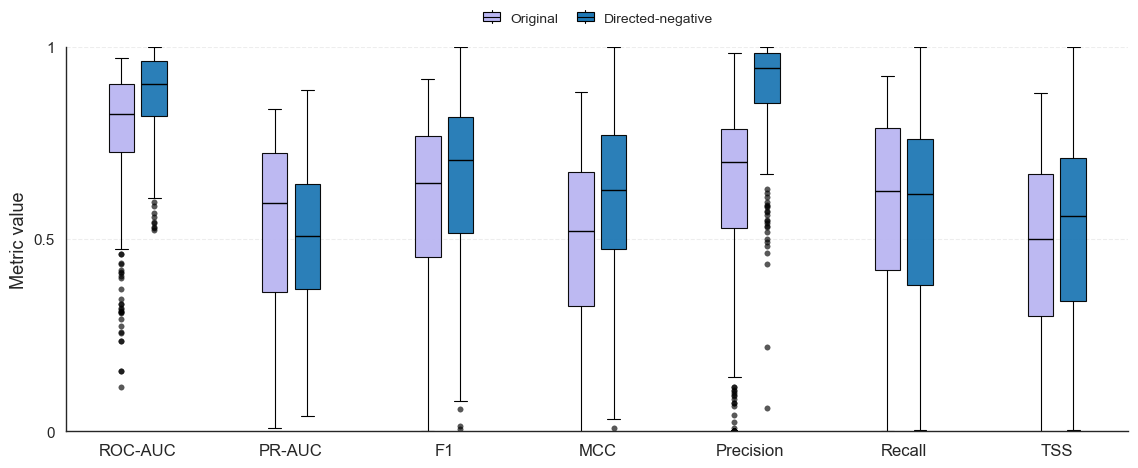

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.1)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
TRAIN_RATIO_TARGET = 90
NODES_THRESHOLD = 0

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / f"predictive_metrics_original_vs_dir_neg_train{TRAIN_RATIO_TARGET}_web_level.png"

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

SHOW_WEB_LEVEL_FLIERS = True

# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    if TRAIN_RATIO_COL not in df.columns:
        print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
        return None

    df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

    if df.empty:
        return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    foodweb = parse_foodweb_from_name(csv_path.name)

    for run_idx, row in df.reset_index(drop=True).iterrows():
        out = {
            "Foodweb": foodweb,
            "Version": version,
            "Run": run_idx + 1,
            "n_runs_in_file_after_filter": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[metric] = float(val) if pd.notna(val) else np.nan
                if pd.notna(val):
                    valid_any = True
            else:
                out[metric] = np.nan

        if valid_any:
            records.append(out)

    return records if records else None


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load run-level CSVs
# ============================================================
rows = []
rows += load_folder(
    RESULTS_DIR_ORIGINAL,
    GLOB_PATTERN_ORIGINAL,
    version="original",
)
rows += load_folder(
    RESULTS_DIR_DIR_NEG,
    GLOB_PATTERN_DIR_NEG,
    version="dir_neg",
)

run_df = pd.DataFrame(rows)

if run_df.empty:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")

# ============================================================
# Apply node filter
# ============================================================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
run_df["FW_KEY"] = run_df["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in run-level results before node filter: {run_df['FW_KEY'].nunique()}")

run_df = run_df[run_df["FW_KEY"].isin(allowed_fw_keys)].copy()

if run_df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")
print(f"[INFO] Run-level rows after filtering: {len(run_df):,}")
print(run_df.groupby("Version").size())

# ============================================================
# Web-level aggregation
# ============================================================
# This is the key correction:
# one row per Foodweb × Version, after averaging repeated runs.
agg_dict = {metric: "mean" for metric in METRICS}
agg_dict["Run"] = "count"

web_df = (
    run_df
    .groupby(["Foodweb", "FW_KEY", "Version"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Run": "ValidRuns"})
)

print(f"[INFO] Web-level rows after averaging runs: {len(web_df):,}")
print(web_df.groupby("Version").agg(
    FoodWebs=("Foodweb", "nunique"),
    MinRuns=("ValidRuns", "min"),
    MedianRuns=("ValidRuns", "median"),
    MaxRuns=("ValidRuns", "max"),
))

# ============================================================
# Summary table
# ============================================================
order = ["original", "dir_neg"]

label_map = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

palette = {
    "original": "#bab6f2",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = web_df.loc[web_df["Version"] == version, metric_col].dropna()

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            "N food webs": int(vals.shape[0]),
            "Mean": vals.mean(),
            "Median": vals.median(),
            "SD": vals.std(ddof=1),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)
for col in ["Mean", "Median", "SD", "Variance"]:
    summary_table[col] = summary_table[col].round(4)

print("\n=== Web-level predictive metric summary ===")
display(summary_table)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            web_df.loc[web_df["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.65,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric value", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/prediction_scores_logs
[INFO] Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

[INFO] Run-level data shape:
(104400, 13)

[INFO] Foodweb count per CvK before web-level averaging:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Raw row count per CvK before web-level averaging:
CvK
3     17400
5     29000
10    58000
dtype: int64

[INFO] Web-level data shape after averaging repeated run/fold rows:
(870, 13)

[INFO] Web-level count and rows averaged per CvK:


,CvK,FoodWebs,TrainRatio,MinRowsAveraged,MedianRowsAveraged,MaxRowsAveraged
0,3,290,66.666667,60,60.0,60
1,5,290,80.000000,100,100.0,100
2,10,290,90.000000,200,200.0,200



=== Web-level k-fold predictive metric summary ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8470,0.8559,0.1103,0.0122
1,3,3-fold (66.7% train),PR-AUC,290,0.5095,0.5161,0.1589,0.0252
2,3,3-fold (66.7% train),F1,290,0.6505,0.6681,0.1950,0.0380
3,3,3-fold (66.7% train),MCC,290,0.5764,0.5707,0.2046,0.0418
4,3,3-fold (66.7% train),Precision,290,0.8451,0.9031,0.1481,0.0219
5,3,3-fold (66.7% train),Recall,290,0.5787,0.6084,0.2202,0.0485
6,3,3-fold (66.7% train),TSS,290,0.5129,0.5064,0.2250,0.0506
7,5,5-fold (80% train),ROC-AUC,290,0.8581,0.8729,0.1065,0.0113
8,5,5-fold (80% train),PR-AUC,290,0.5270,0.5354,0.1539,0.0237
9,5,5-fold (80% train),F1,290,0.6552,0.6900,0.2025,0.0410


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_kfold_web_level.png


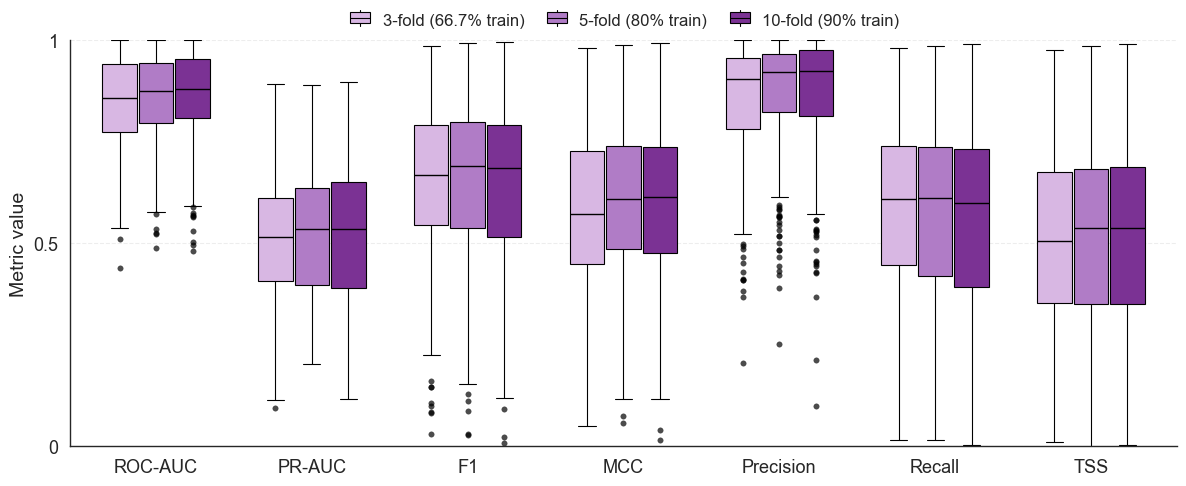

In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
LOG_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "prediction_scores_logs"
)

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_kfold_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_kfold_web_level.png"

PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]

SHOW_WEB_LEVEL_FLIERS = True

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

# ============================================================
# Helpers
# ============================================================
def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }
    if k in train_ratio_map:
        return f"{k}-fold ({train_ratio_map[k]} train)"
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing


def collect_run_level_metrics(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = [
        "CvK",
        "CvK_label",
        "Foodweb",
        "RunRow",
        "TrainRatio",
        "K",
        *METRICS,
    ]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"[INFO] Using LOG_DIR: {log_dir}")
    print(f"[INFO] Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {Path(csv_path).name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {Path(csv_path).name} missing column: CvK")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)
        if missing_metrics:
            print(f"[SKIP] {Path(csv_path).name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()
        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")
        df["TrainRatio"] = pd.to_numeric(df.get("TrainRatio"), errors="coerce")

        if "K" in df.columns:
            df["K"] = pd.to_numeric(df["K"], errors="coerce")
            if K_TARGET is not None:
                df = df[df["K"] == K_TARGET].copy()
        else:
            df["K"] = np.nan

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)
        df["RunRow"] = df.groupby("CvK").cumcount() + 1

        rows.append(df[["CvK", "Foodweb", "RunRow", "TrainRatio", "K", *METRICS]].copy())

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out[expected_cols]


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_kfold_web_level_metrics(df_web: pd.DataFrame) -> None:
    if df_web.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_web["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel("Metric value", fontsize=14)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved figure: {OUT_PATH}")

    plt.show()


# ============================================================
# Run
# ============================================================
df_run = collect_run_level_metrics(LOG_DIR, PATTERN)

print("\n[INFO] Run-level data shape:")
print(df_run.shape)

if df_run.empty:
    print("\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, CvK values, and skipped-file messages above.")
else:
    print("\n[INFO] Foodweb count per CvK before web-level averaging:")
    print(df_run.groupby("CvK")["Foodweb"].nunique())

    print("\n[INFO] Raw row count per CvK before web-level averaging:")
    print(df_run.groupby("CvK").size())

    # ========================================================
    # Key correction:
    # average all repeated run/fold rows within Foodweb × CvK.
    # Each food web contributes one observation per CvK.
    # ========================================================
    agg_dict = {metric: "mean" for metric in METRICS}
    agg_dict.update({
        "RunRow": "count",
        "TrainRatio": "median",
        "K": "median",
    })

    df_web = (
        df_run
        .groupby(["Foodweb", "CvK", "CvK_label"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"RunRow": "RowsAveraged"})
    )

    print("\n[INFO] Web-level data shape after averaging repeated run/fold rows:")
    print(df_web.shape)

    print("\n[INFO] Web-level count and rows averaged per CvK:")
    display(
        df_web
        .groupby("CvK")
        .agg(
            FoodWebs=("Foodweb", "nunique"),
            TrainRatio=("TrainRatio", "median"),
            MinRowsAveraged=("RowsAveraged", "min"),
            MedianRowsAveraged=("RowsAveraged", "median"),
            MaxRowsAveraged=("RowsAveraged", "max"),
        )
        .reset_index()
    )

    summary_rows = []
    for cvk in cvk_order:
        for metric, metric_label in plot_metrics:
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna()
            if vals.empty:
                continue

            summary_rows.append({
                "CvK": cvk,
                "Label": cvk_label(cvk),
                "Metric": metric_label,
                "N food webs": int(vals.shape[0]),
                "Mean": vals.mean(),
                "Median": vals.median(),
                "SD": vals.std(ddof=1),
                "Variance": vals.var(ddof=1),
            })

    summary_table = pd.DataFrame(summary_rows)
    for col in ["Mean", "Median", "SD", "Variance"]:
        summary_table[col] = summary_table[col].round(4)

    print("\n=== Web-level k-fold predictive metric summary ===")
    display(summary_table)

    plot_kfold_web_level_metrics(df_web)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_9201/2026365819.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FOODWEB"] = derive_foodweb_from_filename(path)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_9201/2026365819.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 290


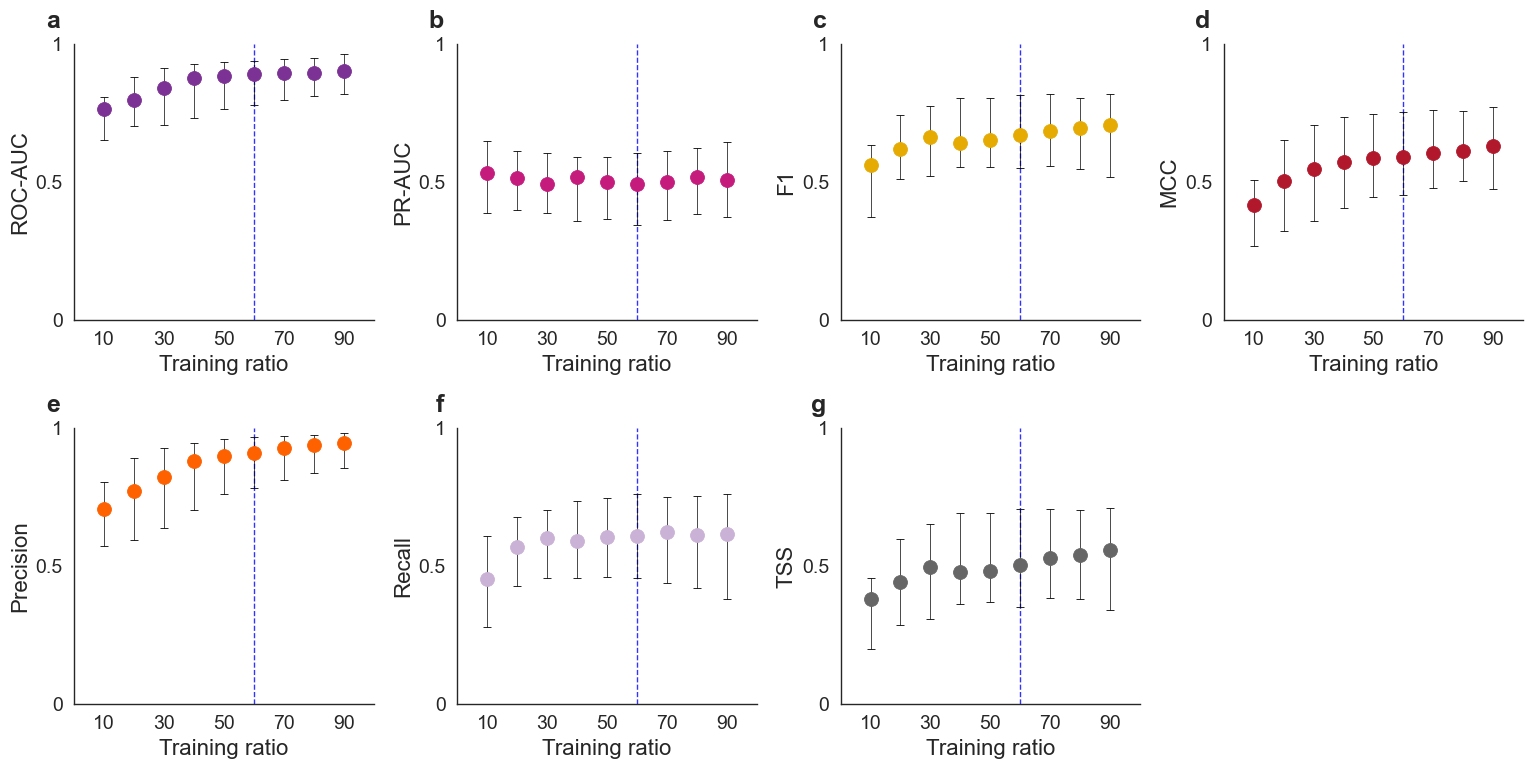

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # brown
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    # Add x-axis label to all panels
    ax.set_xlabel("Training ratio", fontsize=16)

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita_neg_const/statistical_tests/athen/outlier_filtered/train_ratio_60/athen_web_level_metrics_train60_outlier_filtered.csv
[INFO] Loaded outlier-filtered web-level rows: 1,160
[INFO] Plotting rows after empirical/mean-pseudo expansion: 2,320
[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.
[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,296,37,50.0
1,MeanGenerality,290,350,40,49.0
2,MeanTrophicHeight,290,913,19,46.0
3,MeanVulnerability,290,257,41,50.0


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita_neg_const/statistical_tests/athen/outlier_filtered/train_ratio_60/fig5_wlnm_dir_neg_train60_web_level_outlier_filtered.png


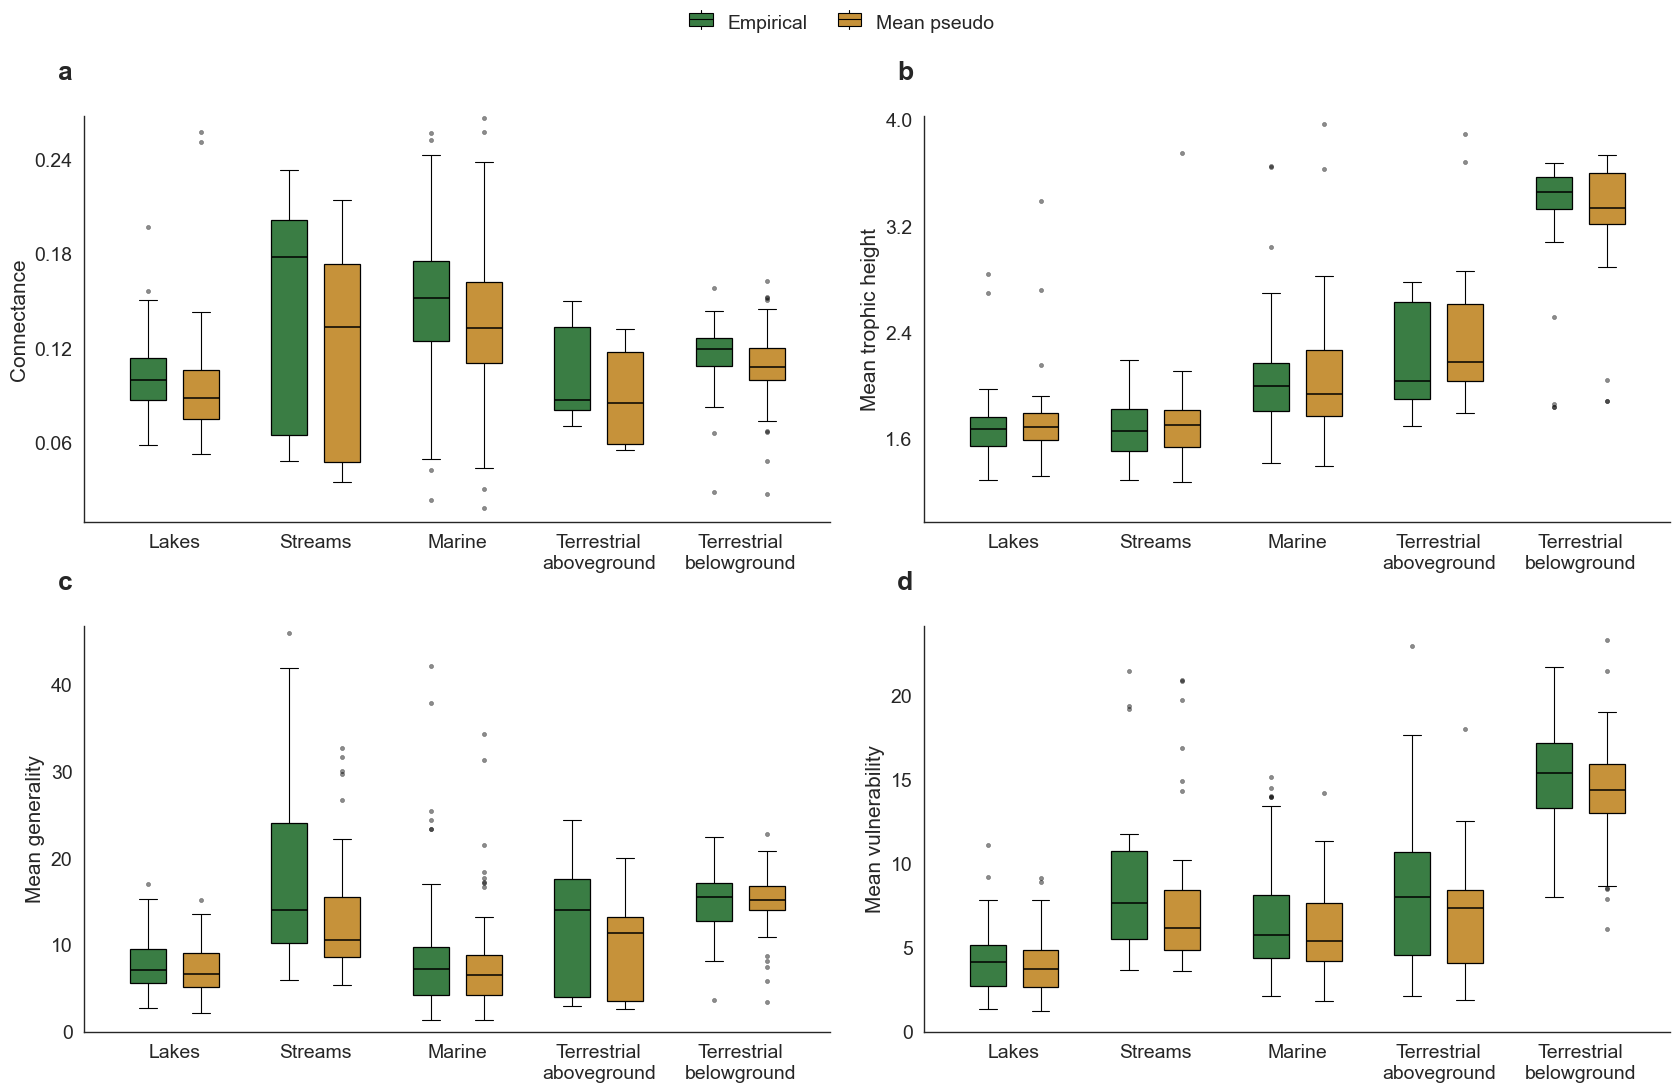

In [3]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIO = 60

ATHEN_OUTLIER_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_stats_Apocrita_neg_const"
    / "statistical_tests/athen/outlier_filtered"
    / f"train_ratio_{TRAIN_RATIO}"
)

ATHEN_WEB_LEVEL_FILTERED = (
    ATHEN_OUTLIER_DIR
    / f"athen_web_level_metrics_train{TRAIN_RATIO}_outlier_filtered.csv"
)

OUT_PATH = (
    ATHEN_OUTLIER_DIR
    / f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_web_level_outlier_filtered.png"
)

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not the pseudo-run outliers.
# Pseudo-run outliers have already been removed before MeanPseudoAfterFiltering.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=False):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD OUTLIER-FILTERED WEB-LEVEL DATA
# ============================================================
athen = pd.read_csv(ATHEN_WEB_LEVEL_FILTERED)

athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)
athen["IncludedAfterFiltering"] = (
    pd.to_numeric(athen["IncludedAfterFiltering"], errors="coerce")
    .fillna(0)
    .astype(int)
)
athen["OutlierRunsRemoved"] = pd.to_numeric(
    athen["OutlierRunsRemoved"],
    errors="coerce",
).fillna(0).astype(int)
athen["ValidRunsAfterFiltering"] = pd.to_numeric(
    athen["ValidRunsAfterFiltering"],
    errors="coerce",
).fillna(0).astype(int)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (athen["Metric"].isin(metric_order))
        & (athen["IncludedAfterFiltering"] == 1)
    ]
    .copy()
)

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Build plotting dataframe:
# one empirical value per food web and one filtered mean pseudo value per food web.
empirical_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
].rename(columns={"EmpiricalValue": "value"})
empirical_df["Web type"] = "Empirical"

pseudo_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "MeanPseudoAfterFiltering"]
].rename(columns={"MeanPseudoAfterFiltering": "value"})
pseudo_df["Web type"] = "Mean pseudo"

plot_df = pd.concat([empirical_df, pseudo_df], ignore_index=True)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

print(f"[INFO] Source file: {ATHEN_WEB_LEVEL_FILTERED}")
print(f"[INFO] Loaded outlier-filtered web-level rows: {len(plot_source):,}")
print(f"[INFO] Plotting rows after empirical/mean-pseudo expansion: {len(plot_df):,}")
print("[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.")
print("[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.")

removed_summary = (
    plot_source
    .groupby("Metric", as_index=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        TotalPseudoRunOutliersRemoved=("OutlierRunsRemoved", "sum"),
        MinRetainedRuns=("ValidRunsAfterFiltering", "min"),
        MedianRetainedRuns=("ValidRunsAfterFiltering", "median"),
    )
)

display(removed_summary)

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Mean pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Mean pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = plot_df[plot_df["Metric"] == metric].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING
    boxplot_groups = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        empirical_values = (
            eco_df[eco_df["Web type"] == "Empirical"]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            eco_df[eco_df["Web type"] == "Mean pseudo"]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(empirical_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Mean pseudo"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_9201/4243354434.py:109: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


[INFO] Filtered results by TrainRatio: kept only TrainRatio = 90.
[INFO] Run-level rows after TrainRatio filter: 14,500
[INFO] Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

[INFO] Run-level observations after filtering:
Total rows in df_merged: 14,500
Rows per ecosystem:
EcosystemType
lakes                      2750
marine                     6700
streams                    1400
terrestrial aboveground    1050
terrestrial belowground    2600
dtype: int64

[INFO] Web-level observations after averaging repeated runs:
Total web-level rows: 290


,EcosystemType,FoodWebs,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,50,50.0,50
1,marine,134,50,50.0,50
2,streams,28,50,50.0,50
3,terrestrial aboveground,21,50,50.0,50
4,terrestrial belowground,52,50,50.0,50



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,0.9844,0.010123
1,marine,134,0.9475,0.019333
2,streams,28,0.9809,0.065596
3,terrestrial aboveground,21,0.9216,0.012597
4,terrestrial belowground,52,0.8806,0.003923



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial belowground (median = 0.8806, variance = 0.003923, n_foodwebs = 52)
Highest median precision: lakes (median = 0.9844, variance = 0.010123, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 0.003923, median = 0.8806, n_foodwebs = 52)
Highest variance:         streams (variance = 0.065596, median = 0.9809, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png


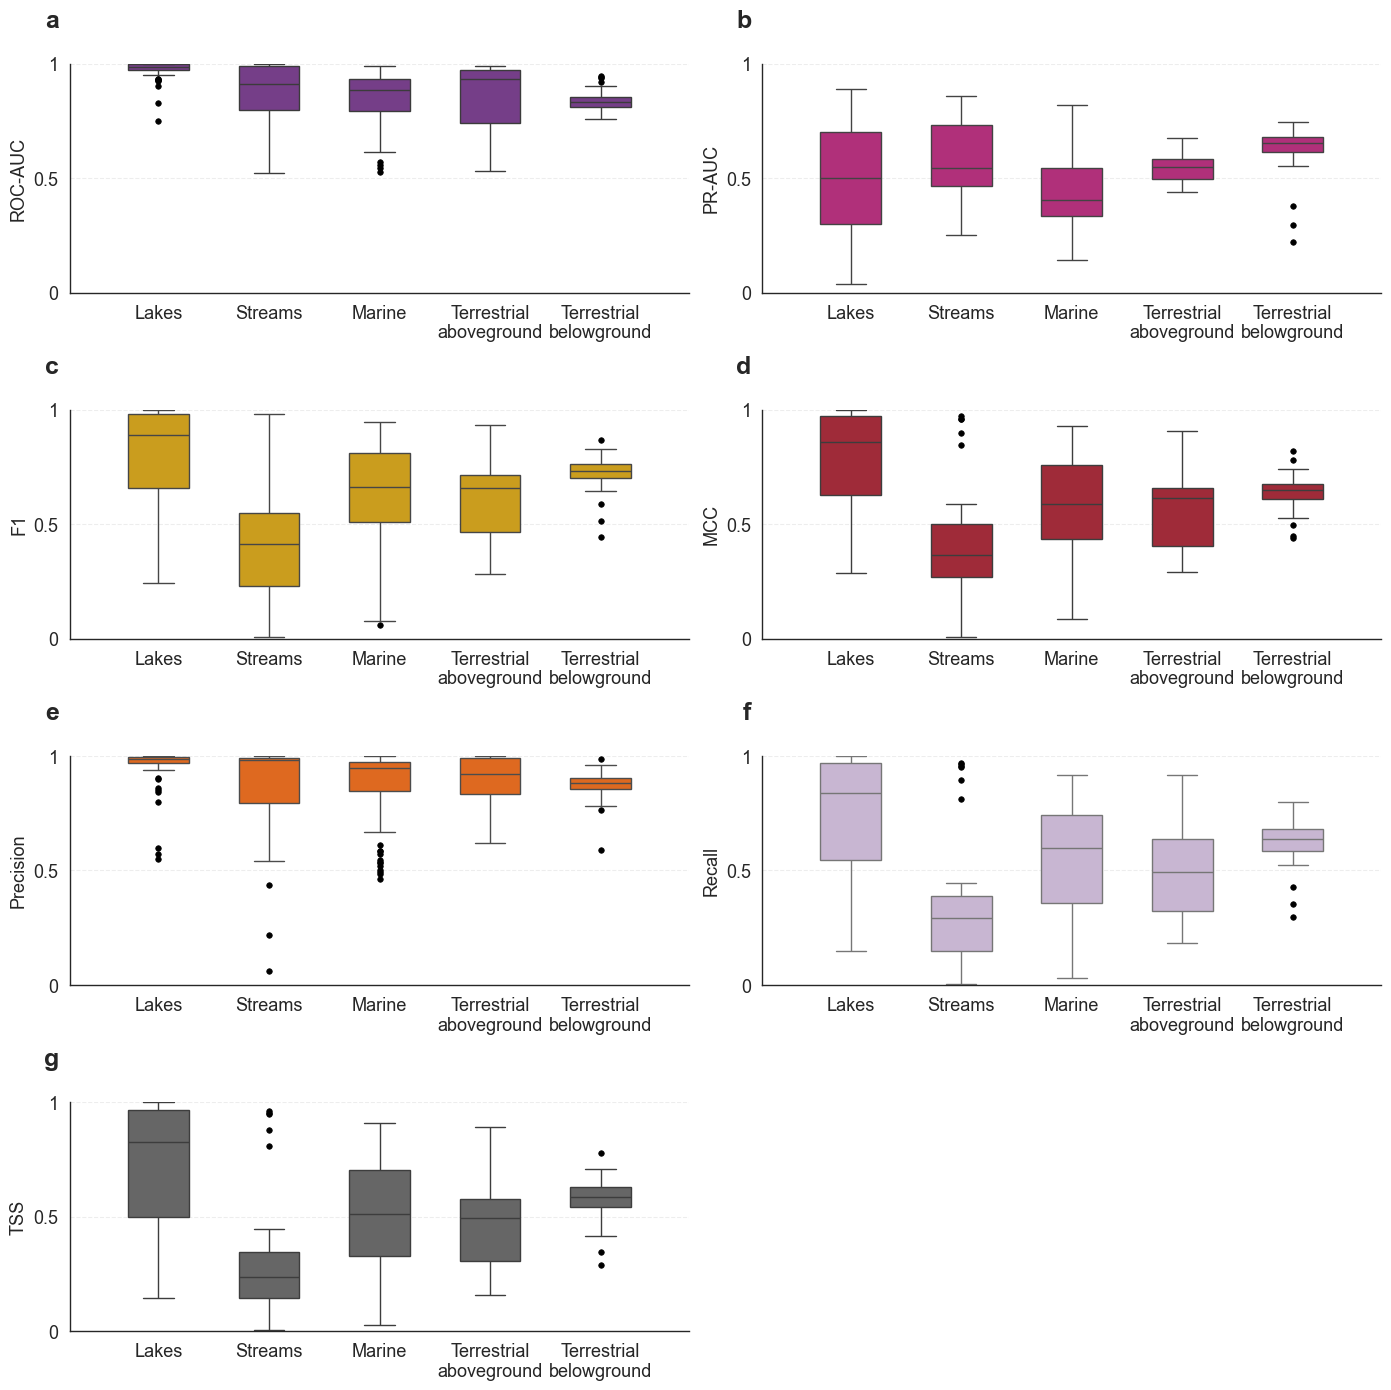

In [11]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context("paper")
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
results_dir = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "prediction_scores_logs"
)

ecosystem_file = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

SHOW_WEB_LEVEL_FLIERS = True

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one, e.g. 'S', 'nodes', 'num_species', or 'node_count'."
    )

# ============================================================
# Load result CSVs
# ============================================================
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# ============================================================
# Filter TrainRatio = 60
# ============================================================
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

for metric in METRIC_ORDER:
    if metric in df_all.columns:
        df_all[metric] = pd.to_numeric(df_all[metric], errors="coerce")
    else:
        raise RuntimeError(f"Metric column '{metric}' not found in result CSVs.")

print(f"[INFO] Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")
print(f"[INFO] Run-level rows after TrainRatio filter: {len(df_all):,}")

# ============================================================
# Merge metrics with ecosystem metadata
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left",
)

# ============================================================
# Apply node-count filter
# ============================================================
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"[INFO] Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

if df_merged.empty:
    raise ValueError(f"No food webs left after filtering Nodes >= {MIN_NODES}.")

print("\n[INFO] Run-level observations after filtering:")
print(f"Total rows in df_merged: {len(df_merged):,}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# ============================================================
# Key correction: web-level aggregation
# ============================================================
# Each food web contributes one observation per metric.
# The 20 repeated WLNM runs are averaged before plotting.
agg_dict = {metric: "mean" for metric in METRIC_ORDER}
agg_dict.update({
    "Iteration": "count",
    node_col: "first",
})

df_web = (
    df_merged
    .groupby(["Foodweb", "EcosystemType"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Iteration": "RunsAveraged"})
)

print("\n[INFO] Web-level observations after averaging repeated runs:")
print(f"Total web-level rows: {len(df_web):,}")
display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        MinRunsAveraged=("RunsAveraged", "min"),
        MedianRunsAveraged=("RunsAveraged", "median"),
        MaxRunsAveraged=("RunsAveraged", "max"),
    )
    .reset_index()
)

# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================
precision_summary = (
    df_web
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Web-level precision median and variance by ecosystem ===")
display(precision_summary)

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")
print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = {lowest_precision['n_foodwebs']})"
)
print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_foodwebs = {highest_precision['n_foodwebs']})"
)
print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_foodwebs = {lowest_variance['n_foodwebs']})"
)
print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_foodwebs = {highest_variance['n_foodwebs']})"
)

# ============================================================
# Prepare long-format web-level data
# ============================================================
df_plot = df_web.melt(
    id_vars=["Foodweb", "EcosystemType", "RunsAveraged"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

# ============================================================
# Preferred ecosystem order
# ============================================================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# ============================================================
# Labels
# ============================================================
labels_map = (
    df_web[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)

def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    return label_replacements.get(eco_lower, eco_clean.capitalize())

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

subset = df_plot.copy()
subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        width=0.55,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = -0.0782x + 0.8840; F1,288 = 0.3293; R² = 0.0011; P = 0.5665; n = 290
b) PR-AUC: y = 0.4224x + 0.4490; F1,288 = 4.0371; R² = 0.0138; P = 0.0454; n = 290
c) F1: y = -0.0169x + 0.6613; F1,288 = 0.0038; R² = 0.0000; P = 0.9510; n = 290
d) MCC: y = -0.4048x + 0.6685; F1,288 = 2.3080; R² = 0.0080; P = 0.1298; n = 290
e) Precision: y = -0.6669x + 0.9775; F1,288 = 15.4867; R² = 0.0510; P = 0.0001; n = 290
f) Recall: y = 0.2231x + 0.5497; F1,288 = 0.5190; R² = 0.0018; P = 0.4719; n = 290
g) TSS: y = -0.2499x + 0.5740; F1,288 = 0.6618; R² = 0.0023; P = 0

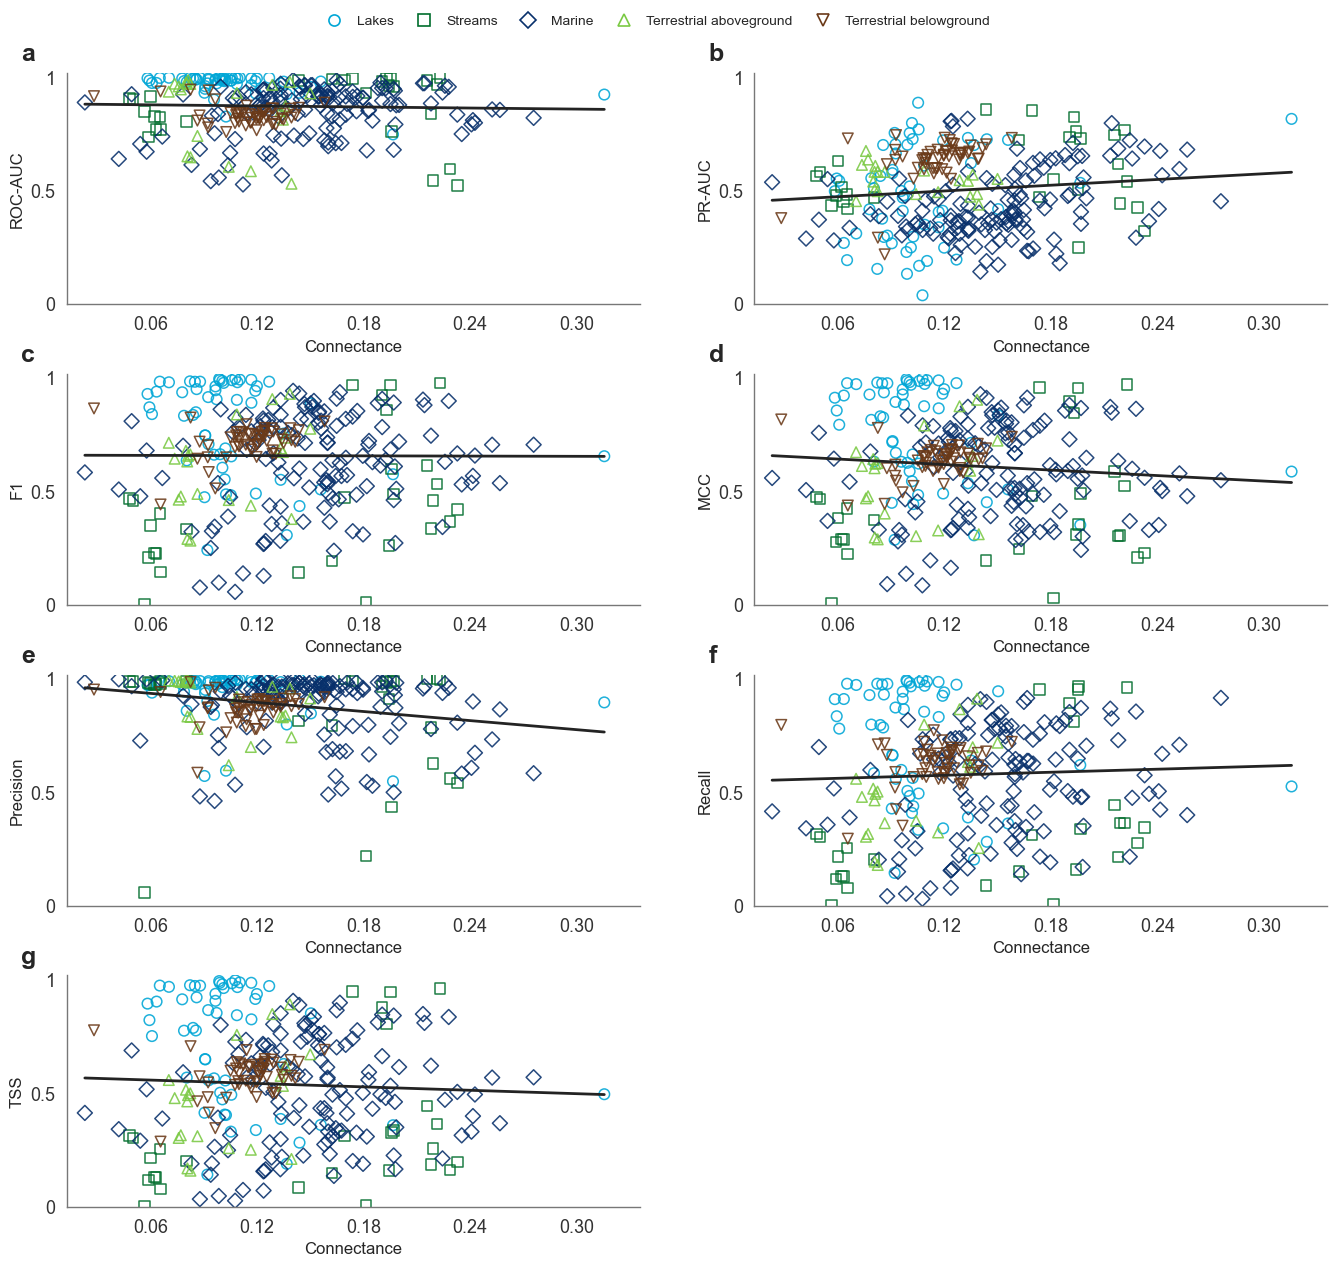

In [12]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    # Removed deprecated copy=False argument to avoid Pandas4Warning.
    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = (
        plot_df["EcosystemType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        eco
        for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        # figsize=(12.5, 4.6 * n_rows),
        figsize=(14, 14),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()
        n_metric_foodwebs = data["Foodweb"].nunique()

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]

            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        # ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(["0", "0.5", "1"])

        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 14500 / 130500. Food webs kept: 290 / 290.

=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.910515 - 0.000571x; F1,288 = 33.4960; R² = 0.1042; P < 0.0001; n = 290
b) PR-AUC: y = 0.473211 + 0.000491x; F1,288 = 9.5206; R² = 0.0320; P = 0.0022; n = 290
c) F1: y = 0.696566 - 0.000581x; F1,288 = 7.8384; R² = 0.0265; P = 0.0055; n = 290
d) MCC: y = 0.653397 - 0.000597x; F1,288 = 8.7704; R² = 0.0296; P = 0.0033; n = 290
e) Precision: y = 0.879083 + 0.000156x; F1,288 = 1.3858; R² = 0.0048; P = 0.2401; n = 290
f) Recall: y = 0.640891 - 0.000956x; F1,288 = 17.2531; R² = 0.0565; P < 0.0001; n = 290
g) TSS: y = 0.595595 - 0.000847x; F1,288 = 13.5758; R² = 0.0450; P = 0.0003; n = 290


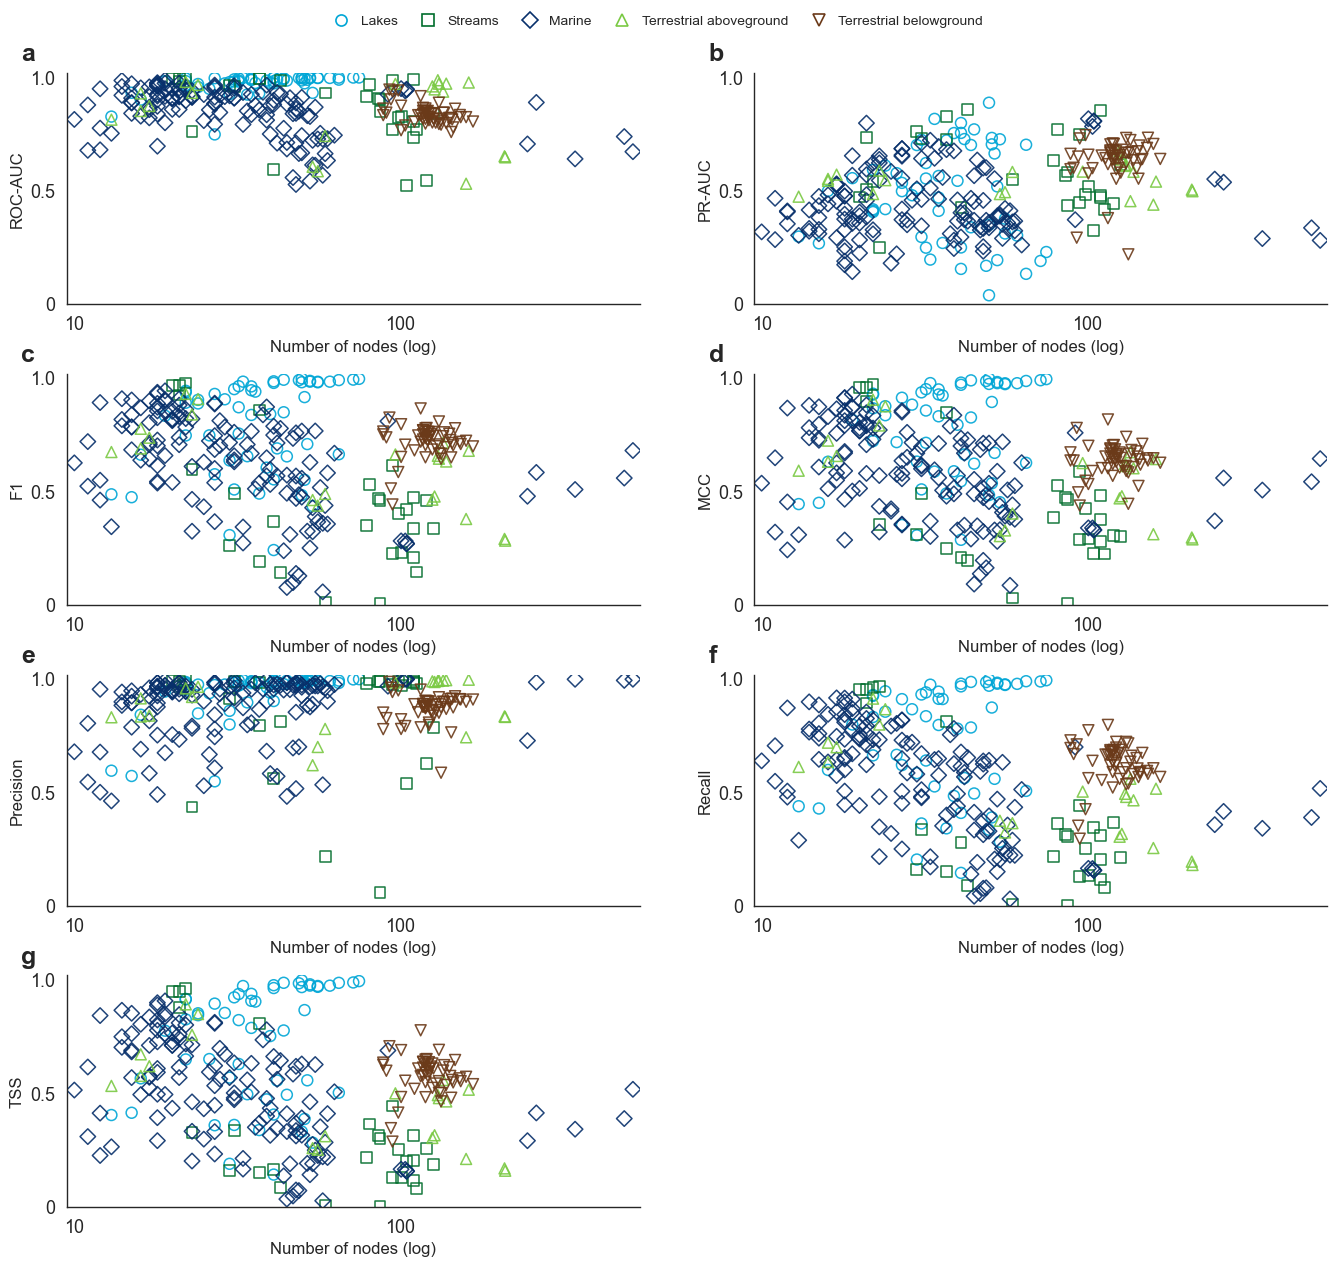

In [13]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, ScalarFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

RESULTS_DIR = Path(
    "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties_Apocrita_neg_const/prediction_scores_logs"
)
ECOSYSTEM_FILE = Path(
    "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.6f} {sign} {abs(slope):.6f}x"


# ============================================================
# Regression helper
# ============================================================

def fit_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_points: int = 100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:
        metric ~ Nodes

    The x-axis is linear, so Nodes are used directly without log transformation.
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = work[x_col].astype(float)
    work[y_col] = work[y_col].astype(float)

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({x_col: x_line})
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "p_value": model.pvalues[x_col],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(
    df_ecosystem,
    ["ecosystemtype", "ecosystem", "ecosystem_type"],
)
nodes_col = find_column(
    df_ecosystem,
    ["nodes", "n_nodes", "num_nodes", "nodecount", "s"],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        ecosystem_col: "EcosystemType",
        nodes_col: "Nodes",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "EcosystemType",
        "Nodes",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

df_ecosystem = df_ecosystem.drop_duplicates(subset=["FoodwebKey"]).copy()


# ============================================================
# Load results
# ============================================================

csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))

if not csv_files:
    raise RuntimeError(
        f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}"
    )

frames = []

for file in csv_files:
    df = pd.read_csv(file).copy()

    foodweb = extract_foodweb_name(file)
    foodweb_key = normalize_foodweb_name(foodweb)

    file_meta = pd.DataFrame(
        {
            "Foodweb": foodweb,
            "FoodwebKey": foodweb_key,
        },
        index=df.index,
    )

    df = pd.concat([df, file_meta], axis=1).copy()
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True).copy()

if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"}).copy()

if "TestMCC" not in df_all.columns and "MCC" in df_all.columns:
    df_all = df_all.rename(columns={"MCC": "TestMCC"}).copy()

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]

if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")


# ============================================================
# Merge + filter
# ============================================================

df_merged = df_all.merge(
    df_ecosystem[["FoodwebKey", "EcosystemType", "Nodes"]],
    on="FoodwebKey",
    how="left",
).copy()

if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = normalize_train_ratio(df_merged["TrainRatio"])
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")
df_merged["EcosystemType"] = df_merged["EcosystemType"].fillna("Unknown")

numeric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
    "TestTPR",
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    np.isclose(df_merged["TrainRatio"], TARGET_RATIO, equal_nan=False)
    & (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}

df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
    .copy()
)

df_scatter = df_scatter.dropna(subset=["Nodes"]).copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

x_min = max(1, df_scatter["Nodes"].min() * 0.95)
x_max = min(X_MAX, df_scatter["Nodes"].max() * 1.05)


# ============================================================
# Ecosystem order + palette
# ============================================================

available_ecosystems = (
    df_scatter["EcosystemType"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(eco): eco
    for eco in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    eco
    for eco in available_ecosystems
    if eco not in eco_order
]

df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}


# ============================================================
# Plot
# ============================================================

n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")
total_foodwebs = df_scatter["Foodweb"].nunique()

print("\n=== OLS linear regression: metric ~ number of nodes ===")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    data = df_scatter.dropna(subset=["Nodes", metric_col]).copy()
    n_metric_foodwebs = data["Foodweb"].nunique()

    for eco in eco_order:
        sub = data[data["EcosystemType"] == eco]

        if sub.empty:
            continue

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    fit = fit_linear_regression(data, "Nodes", metric_col)

    if fit is not None:
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(fit["intercept"], fit["slope"])
        p_text = format_p_value(fit["p_value"])

        print(
            f"{panel_letters[i]}) {metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
            f"R² = {fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[i]}) {metric_label}: "
            "regression not fitted; insufficient data."
        )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Number of nodes (log)", fontsize=12)

    ax.tick_params(axis="x", labelbottom=True, labelsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1.0"], fontsize=13)

    sns.despine(ax=ax)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


# ============================================================
# Figure-level legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[eco],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[eco],
        markeredgewidth=1.2,
        label=format_ecosystem_label(eco),
    )
    for eco in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()

---